# Initialize

In [3]:
visible_devices = [3]
from datetime import datetime
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "Importing os...")
import os
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "Importing sys...")
import sys
sys.dont_write_bytecode = True
print("Visible devices:", visible_devices)
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "Importing timer from timeit...")
from timeit import default_timer as timer
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "Setting env variables for tf import (only device", visible_devices, "will be available)...")
os.environ["CUDA_VISIBLE_DEVICES"] = ','.join([str(i) for i in visible_devices])
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
#os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
#os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=2'
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "Importing numpy...")
import numpy as np
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "Importing pandas...")
import pandas as pd
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "Importing subprocess...")
import subprocess
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "Importing tensorflow...")
import tensorflow as tf
print("Tensorflow version:", tf.__version__)
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "Importing tensorflow_probability...")
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors
print("Tensorflow probability version:", tfp.__version__)
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "Importing typing...")
from typing import List, Tuple, Dict, Union, Optional, Any
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "Setting tf configs...")
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
for gpu_device in gpu_devices:
    tf.config.experimental.set_memory_growth(gpu_device, True)

print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "Importing NFTF2 module...")

sys.path.append('../')
import Bijectors, Distributions, MixtureDistributions, Plotters, Trainer, Utils # type: ignore

print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "Importing GMetrics module...")


sys.path.append('../../../')
import GMetrics # type: ignore
from GMetrics.plotters import plot_corners, cornerplotter, plot_corr_matrix, plot_corr_matrix_side_by_side # type: ignore
from GMetrics.more import deformations # type: ignore
from GMetrics.more.optimizers_deformations import compute_exclusion_bisection, compute_exclusion_LR_bisection # type: ignore
from GMetrics.utils import se_mean, se_std
from GMetrics.notebooks import shared

def get_gpu_info() -> Optional[List[str]]:
    try:
        gpu_info: str = subprocess.check_output(["nvidia-smi", "--query-gpu=gpu_name", "--format=csv,noheader"]).decode('utf-8')
        return gpu_info.strip().split('\n')
    except Exception as e:
        print(e)
        return None
gpu_models: Optional[List[str]] = get_gpu_info()
if gpu_models:
    training_device: str = gpu_models[0]
    print("Successfully loaded GPU model: {}".format(training_device))
else:
    training_device = 'undetermined'
    print("Failed to load GPU model. Defaulting to 'undetermined'.")
    
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "All modues imported successfully.")

mother_output_dir = 'outputs/'
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")+":", "Output directory set to", os.path.abspath(mother_output_dir))

2025-05-27 18:08:48.923991: Importing os...
2025-05-27 18:08:48.924091: Importing sys...
Visible devices: [3]
2025-05-27 18:08:48.924178: Importing timer from timeit...
2025-05-27 18:08:48.924230: Setting env variables for tf import (only device [3] will be available)...
2025-05-27 18:08:48.924339: Importing numpy...
2025-05-27 18:08:48.924386: Importing pandas...
2025-05-27 18:08:48.924443: Importing subprocess...
2025-05-27 18:08:48.924486: Importing tensorflow...
Tensorflow version: 2.12.0
2025-05-27 18:08:48.924552: Importing tensorflow_probability...
Tensorflow probability version: 0.20.1
2025-05-27 18:08:48.924645: Importing typing...
2025-05-27 18:08:48.925265: Setting tf configs...
2025-05-27 18:08:48.925418: Importing NFTF2 module...
2025-05-27 18:08:48.925508: Importing GMetrics module...
Successfully loaded GPU model: Tesla V100S-PCIE-32GB
2025-05-27 18:08:48.962528: All modues imported successfully.
2025-05-27 18:08:48.962636: Output directory set to /auto_home/users/acosso

# Useful functions

In [4]:
def reset_random_seeds(seed):
    os.environ['PYTHONHASHSEED']=str(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

In [5]:
def MixtureGaussian(ncomp: int,
                    ndims: int,
                    seed: int = 0) -> tfp.distributions.Mixture:
    targ_dist: tfp.distributions.Mixture = MixtureDistributions.MixMultiNormal1(ncomp,ndims,seed=seed)
    return targ_dist

In [6]:
def get_io_kwargs(path_to_results: str) -> Dict[str,Any]:
    return {'results_path': path_to_results,
            'load_weights': True,
            'load_results': True}

In [7]:
def get_data_kwargs(seed: int = 0) -> Dict[str,Any]:
    return {'seed': seed}

In [8]:
def get_compiler_kwargs(lr: float,
                        ignore_nans: bool,
                        nan_threshold: float
                       ) -> Dict[str,Any]:
    #compiler_kwargs = {'optimizer': {'class_name': 'Adam', # this gives the new Adam optimizer
    compiler_kwargs = {'optimizer': {'class_name': 'Custom>Adam', # this gives the new Adam optimizer
                                     'config': {'learning_rate': lr,
                                                'beta_1': 0.9,
                                                'beta_2': 0.999,
                                                'epsilon': 1e-07,
                                                'amsgrad': True}},
                       'metrics': [{'class_name': 'MinusLogProbMetric',
                                    'config': {'ignore_nans': ignore_nans, 
                                               'debug_print_mode': False}}],
                       'loss': {'class_name': 'MinusLogProbLoss', 
                                'config': {'name': "MLP", 
                                           'ignore_nans': ignore_nans, 
                                           'nan_threshold': nan_threshold, 
                                           'debug_print_mode': False}}}
    return compiler_kwargs

In [9]:
def get_callbacks_kwargs(checkpoint_path: str,
                         es_min_delta: float,
                         es_patience: int,
                         lr_reduce_factor: float,
                         lr_min_delta: float,
                         lr_patience: int,
                         min_lr: float
                         ) -> List[Dict[str,Any]]:
    callbacks_kwargs = [{'class_name': 'PrintEpochInfo',
                         'config': {}},
                        #{'class_name': 'HandleNaNCallback',
                        # 'config': {'checkpoint_path': checkpoint_path,
                        #            'lr_reduction_factor': lr_reduce_factor_on_nan,
                        #            'random_seed_var': np.random.randint(1000000)}},
                        #{'class_name': 'TerminateOnNaNFractionCallback',
                        # 'config': {'threshold': 0.1,
                        #            'validation_data': X_data_val}},
                        {'class_name': 'ModelCheckpoint',
                         'config': {'filepath': checkpoint_path,
                                    'monitor': 'val_loss',
                                    'save_best_only': True,
                                    'save_weights_only': True,
                                    'verbose': 1,
                                    'mode': 'auto',
                                    'save_freq': 'epoch'}},
                        {'class_name': 'EarlyStopping',
                         'config': {'monitor': 'val_loss', 
                                    'min_delta': es_min_delta, 
                                    'patience': es_patience, 
                                    'verbose': 1,
                                    'mode': 'auto', 
                                    'baseline': None, 
                                    'restore_best_weights': True}},
                        {'class_name': 'ReduceLROnPlateau', 
                         'config': {'monitor': 'val_loss', 
                                    'factor': lr_reduce_factor, 
                                    'min_delta': lr_min_delta, 
                                    'patience': lr_patience, 
                                    'min_lr': min_lr}},
                        {'class_name': 'TerminateOnNaN', 'config': {}}
                        ]
    return callbacks_kwargs

In [10]:
def get_fit_kwargs(batch_size: int,
                   epochs_input: int,
                   validation_data: Tuple[Union[np.ndarray,tf.Tensor],Union[np.ndarray,tf.Tensor]],
                   shuffle: bool,
                   verbose: int
                  ) -> Dict[str,Any]:
    fit_kwargs = {'batch_size': batch_size, 
                  'epochs': epochs_input, 
                  'validation_data': validation_data,
                  'shuffle': shuffle, 
                  'verbose': verbose}
    return fit_kwargs

# Train model

## Define distributions (Base and Target)

In [11]:
# Run number (related to the folder where results are saved)
run_number: int = 0
n_runs: int = 1

# Define number of dimensions and number of components for the mixture model
ndims: int = 5
ncomp: int = 3

# Define seeds
seed_train: int
seed_test: int
seed_dist: int
seed_metrics: int
seed_train, seed_test, seed_dist, seed_metrics = [0,0,0,0]
seed_test = seed_train + 1                     
Utils.reset_random_seeds(seed = seed_dist)

# Define base and target distributions
targ_dist: tfp.distributions.Distribution = MixtureGaussian(ncomp = ncomp, ndims = ndims, seed = seed_dist)
base_dist: tfp.distributions.Distribution = Distributions.gaussians(ndims)

# Define data
nsamples_train: int
nsamples_val: int
nsamples_test: int
nsamples_train, nsamples_val, nsamples_test = [10000, 3000, 3000]
X_data_train: tf.Tensor
X_data_val: tf.Tensor
Y_data_train: tf.Tensor
Y_data_val: tf.Tensor
X_data_train, X_data_val, Y_data_train, Y_data_val = Utils.generate_train_data(run_number = run_number,
                                                                               targ_dist = targ_dist,
                                                                               nsamples_train = nsamples_train,
                                                                               nsamples_val = nsamples_val,
                                                                               seed_train = seed_train)
print("X_data_train shape:", X_data_train.shape)
print("Y_data_train shape:", Y_data_train.shape)

Generating train data for run 0.
Train data generated in 0.08 s.

X_data_train shape: (10000, 5)
Y_data_train shape: (10000, 0)


## Initialize bijector

In [12]:
### Initialize bijector inputs ###
bijector_name: str = 'MAFN'
range_min: int = -16
spline_knots: Optional[int] = 3
nbijectors: int = 3

### Initialize NN hyperparameters ###
hidden_layers: int = [32,32,32]
activation: str = 'relu'
regulariser: Optional[str] = None
eps_regulariser: float = 0.

In [13]:
bijector: tfp.bijectors.Bijector = Bijectors.ChooseBijector(bijector_name = bijector_name,
                                                            ndims = ndims,
                                                            spline_knots = spline_knots,
                                                            nbijectors = nbijectors,
                                                            range_min = range_min,
                                                            hidden_layers = hidden_layers,
                                                            activation = activation,
                                                            regulariser = regulariser,
                                                            eps_regulariser = eps_regulariser)

In [14]:
# assuming nf_dist is your TransformedDistribution
for i, b in enumerate(bijector.bijectors):
    print(f"Bijector #{i}:")
    print("  name       =", b.name)
    print("  type       =", type(b))
    print("  tran_ndims =", getattr(b, "tran_ndims", None))
    print("  forward_min_event_ndims =", b.forward_min_event_ndims)
    print()


Bijector #0:
  name       = MAF_2
  type       = <class 'tensorflow_probability.python.bijectors.masked_autoregressive.MaskedAutoregressiveFlow'>
  tran_ndims = None
  forward_min_event_ndims = 1

Bijector #1:
  name       = perm_1
  type       = <class 'tensorflow_probability.python.bijectors.permute.Permute'>
  tran_ndims = None
  forward_min_event_ndims = 1

Bijector #2:
  name       = MAF_1
  type       = <class 'tensorflow_probability.python.bijectors.masked_autoregressive.MaskedAutoregressiveFlow'>
  tran_ndims = None
  forward_min_event_ndims = 1

Bijector #3:
  name       = perm_0
  type       = <class 'tensorflow_probability.python.bijectors.permute.Permute'>
  tran_ndims = None
  forward_min_event_ndims = 1

Bijector #4:
  name       = MAF_0
  type       = <class 'tensorflow_probability.python.bijectors.masked_autoregressive.MaskedAutoregressiveFlow'>
  tran_ndims = None
  forward_min_event_ndims = 1



## Initialize a Trainer

In [15]:
### Base run directory ###
path_to_results , _ = Utils.define_run_dir(mother_output_dir+'run_'+str(run_number)+'/',
                                           force = "skip",
                                           bkp = False)

### Compiler hyperparameters ###
lr: float = 0.001
ignore_nans: bool = True
nan_threshold: float = 0.01

### Initialize callbacks hyperparameters ###
path_to_weights: str = Utils.define_dir(os.path.join(path_to_results, 'weights'))
checkpoint_path: str = os.path.join(path_to_weights, 'best_weights.h5')
es_min_delta: float = .0001
es_patience: int = 100
lr_reduce_factor: float = .5
lr_min_delta: float = .0001
lr_patience: int = 50
min_lr: float = 1e-6

### Initialzie training hyperparameters ###
batch_size: int = 512
epochs_input: int = 100
shuffle: bool = True
verbose_trainer: int = 2

### Debugging parameter
debug_print_mode: bool = False


Directory outputs/run_0/ already exists.
Skipping it.


In [16]:
NFObject: Trainer.Trainer = Trainer.Trainer(base_distribution = base_dist,
                                            flow = bijector, 
                                            x_data_train = X_data_train,
                                            y_data_train = Y_data_train,
                                            io_kwargs = get_io_kwargs(path_to_results = path_to_results),
                                            data_kwargs = get_data_kwargs(seed = seed_train),
                                            compiler_kwargs = get_compiler_kwargs(lr = lr,
                                                                                  ignore_nans = True,
                                                                                  nan_threshold = nan_threshold),
                                            callbacks_kwargs = get_callbacks_kwargs(checkpoint_path = checkpoint_path,
                                                                                    es_min_delta = es_min_delta,
                                                                                    es_patience = es_patience,
                                                                                    lr_reduce_factor = lr_reduce_factor,
                                                                                    lr_min_delta = lr_min_delta,
                                                                                    lr_patience = lr_patience,
                                                                                    min_lr = min_lr),
                                            fit_kwargs = get_fit_kwargs(batch_size = batch_size,
                                                                        epochs_input = epochs_input,
                                                                        validation_data = (X_data_val, Y_data_val),
                                                                        shuffle = shuffle,
                                                                        verbose = verbose_trainer),
                                            debug_print_mode = debug_print_mode)
trainable_params: int = NFObject.trainable_params
non_trainable_params: int = NFObject.non_trainable_params

********************************************found custom MAF
data:  KerasTensor(type_spec=TensorSpec(shape=(None, 5), dtype=tf.float32, name=None), name='tf.__operators__.getitem/strided_slice:0', description="created by layer 'tf.__operators__.getitem'")
cond:  KerasTensor(type_spec=TensorSpec(shape=(None, 0), dtype=tf.float32, name=None), name='tf.__operators__.getitem_1/strided_slice:0', description="created by layer 'tf.__operators__.getitem_1'")
********************** using conditionals in a chain *********************


z:  KerasTensor(type_spec=TensorSpec(shape=(None, 5), dtype=tf.float32, name=None), name='tf.math.multiply_2/Mul:0', description="created by layer 'tf.math.multiply_2'")
ildj:  KerasTensor(type_spec=TensorSpec(shape=(None,), dtype=tf.float32, name=None), name='tf.identity_9/Identity:0', description="created by layer 'tf.identity_9'")
Model defined.
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 5)]          0           []                               
                                                                                                  
 tf.__operators__.getitem (Slic  (None, 5)           0           ['input_1[0][0]']                
 ingOpLambda)                                                                                     
                                        

## Store/save hyperparameters

In [ ]:
### Initialize dictionaries to store paramerers and results ###
results_dict: Dict[str, Any] = Utils.init_results_dict()
hyperparams_dict: Dict[str, Any] = Utils.init_hyperparams_dict()

### Create log file ###
log_file_name: str = Utils.create_log_file(mother_output_dir, results_dict)

In [ ]:
hyperparams_dict = Utils.update_hyperparams_dict(hyperparams_dict = hyperparams_dict,
                                                 run_number = run_number,
                                                 n_runs = n_runs,
                                                 seeds = [seed_train, seed_test, seed_dist, seed_metrics],
                                                 nsamples = [nsamples_train, nsamples_val, nsamples_test],
                                                 ndims = ndims,
                                                 corr = None,
                                                 bijector_name = bijector_name,
                                                 nbijectors = nbijectors,
                                                 spline_knots = spline_knots,
                                                 range_min = range_min,
                                                 hllabel = '-'.join(str(e) for e in hidden_layers),
                                                 trainable_parameters = trainable_params,
                                                 non_trainable_parameters = non_trainable_params,
                                                 batch_size = batch_size,
                                                 epochs_input = epochs_input,
                                                 activation = activation,
                                                 regulariser = regulariser,
                                                 eps_regulariser = eps_regulariser,
                                                 training_device = training_device)
Utils.save_hyperparams_dict(path_to_results, hyperparams_dict)

Running 0/1 with hyperparameters:
timestamp = 2025-05-27 18:08:50.270615
ndims = 5
seed_train = 0
nsamples_train = 10000
nsamples_val = 3000
nsamples_test = 3000
bijector = MAFN
nbijectors = 3
spline_knots = 3
range_min = -16
hidden_layers = 32-32-32
trainable_parameters = 7902
epochs_input = 100
batch_size = 512
activation = relu
training_device = Tesla V100S-PCIE-32GB



## Train

In [19]:
NFObject.train()

Epoch 1/100


2025-05-27 18:08:53.777 
Epoch 1/100 
	 loss: 5.5546, MinusLogProbMetric: 5.5546, val_loss: 5.1494, val_MinusLogProbMetric: 5.1494

Epoch 1: val_loss improved from inf to 5.14942, saving model to /auto_home/users/acosso/RealNVP_test/cond_bijectors/notebooks/outputs/run_0/weights/best_weights.h5
20/20 - 3s - loss: 5.5546 - MinusLogProbMetric: 5.5546 - val_loss: 5.1494 - val_MinusLogProbMetric: 5.1494 - lr: 0.0010 - 3s/epoch - 175ms/step
Epoch 2/100
2025-05-27 18:08:53.985 
Epoch 2/100 
	 loss: 5.0326, MinusLogProbMetric: 5.0326, val_loss: 4.9483, val_MinusLogProbMetric: 4.9483

Epoch 2: val_loss improved from 5.14942 to 4.94832, saving model to /auto_home/users/acosso/RealNVP_test/cond_bijectors/notebooks/outputs/run_0/weights/best_weights.h5
20/20 - 1s - loss: 5.0326 - MinusLogProbMetric: 5.0326 - val_loss: 4.9483 - val_MinusLogProbMetric: 4.9483 - lr: 0.0010 - 923ms/epoch - 46ms/step
Epoch 3/100
2025-05-27 18:08:54.912 
Epoch 3/100 
	 loss: 4.9361, MinusLogProbMetric: 4.9361, val_loss

# Test model with fixed $n=10000$

## Null hypotheses

### Model definition

In [20]:
batch_size_test = 10_000

In [21]:
model_dir = path_to_results
if os.path.exists(model_dir):
    print("Model directory exists")
else:
    os.makedirs(model_dir)
    print("Model directory was created")
null_hypotheses_dir = model_dir + "null_hypothesis/"
if os.path.exists(null_hypotheses_dir):
    print("Null hypothesis directory exists")
else:
    os.makedirs(null_hypotheses_dir)
    print("Null hypothesis directory was created")
metrics_config_file = model_dir + "metrics_config.json"

Model directory exists
Null hypothesis directory exists


In [22]:
niter = 10_000
TwoSampleTestInputs = GMetrics.TwoSampleTestInputs(dist_1_input = targ_dist,
                                                   dist_2_input = NFObject.nf_dist,
                                                   niter = niter,
                                                   batch_size_test = batch_size_test,
                                                   batch_size_gen = 10_000,
                                                   small_sample_threshold = 1e7,
                                                   dtype_input = tf.float32,
                                                   seed_input = seed_test,
                                                   use_tf = True,
                                                   mirror_strategy = False,
                                                   verbose = True)
print("nsamples",TwoSampleTestInputs.nsamples)
print("batch_size",TwoSampleTestInputs.batch_size_test)
print("niter",TwoSampleTestInputs.niter)
print("niter * batch_size",TwoSampleTestInputs.niter*TwoSampleTestInputs.batch_size_test)
print("small_sample",TwoSampleTestInputs.small_sample)

Parsing input distribution...
Input distribution is a tfp.distributions.Distribution object.


Parsing input distribution...
Input distribution is a tfp.distributions.Distribution object.
Checking and setting numerical distributions.
Resetting dist_num.
Resetting dist_num.
nsamples 100000000
batch_size 10000
niter 10000
niter * batch_size 100000000
small_sample False


In [23]:
KSTest = GMetrics.KSTest(TwoSampleTestInputs,
                         progress_bar = True,
                         verbose = True)
SKSTest = GMetrics.SKSTest(TwoSampleTestInputs,
                           nslices = 100, # to be included in metric kwargs
                           seed_slicing = 0, # to be included in metric kwargs
                           progress_bar = True,
                           verbose = True)
SWDMetric = GMetrics.SWDMetric(TwoSampleTestInputs,
                               nslices = 100, # to be included in metric kwargs
                               seed_slicing = 0, # to be included in metric kwargs
                               progress_bar = True,
                               verbose = True)
FGDMetric = GMetrics.FGDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               num_batches = 20, # to be included in metric kwargs
                               num_points = 10, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs
MMDMetric = GMetrics.MMDMetric(TwoSampleTestInputs,
                               progress_bar = True,
                               verbose = True,
                               degree = 4, # to be included in metric kwargs
                               block_size = 10_000, # to be included in metric kwargs
                               normalise = False) # to be included in metric kwargs
LRMetric = GMetrics.LRMetric(TwoSampleTestInputs,
                             null_test=True,
                             verbose = True)

Generating random directions based on nslices, ndims, and seed_slicing.
Generating random directions based on nslices, ndims, and seed_slicing.
To run under the alternative hypothesis, set the `null_test` attribute to False.


### Set up tests and metrics configurations

In [24]:
test_config_null = {}
test_config_tmp = dict(TwoSampleTestInputs.__dict__)
keys_to_remove = ["_dist_1_input", "_dist_2_input", "_dist_1_num", "_dist_2_num", "_dist_1_symb", "_dist_2_symb", "_seed_generator"]
for key in keys_to_remove:
    test_config_tmp.pop(key, None)
for key, value in test_config_tmp.items():
    new_key = key.lstrip('_')
    
    if isinstance(value, tf.Tensor):
        new_value = value.numpy() # type: ignore
    elif isinstance(value, np.ndarray):
        new_value = value.tolist()
    elif isinstance(value, np.generic):
        new_value = value.item() # Convert NumPy scalars to Python scalars
    elif isinstance(value, tf.DType):
        new_value = value.name
    elif isinstance(value, np.dtype):
        new_value = np.dtype(value).name
    else:
        new_value = value
    
    test_config_null[new_key] = new_value

test_config_null["ncomp"] = ncomp

pd.DataFrame([test_config_null])

,niter,batch_size_test,batch_size_gen,small_sample_threshold,dtype_input,seed,use_tf,mirror_strategy,strategy,verbose,...,ndims_1,nsamples_1,is_symb_2,ndims_2,nsamples_2,dtype,ndims,nsamples,small_sample,ncomp
0,10000,10000,10000,10000000,float32,1,True,False,None,True,...,5,0,True,5,0,float32,5,100000000,False,3


In [ ]:
unique_key = "config_ndims_"+str(TwoSampleTestInputs.ndims)+"_ncop_"+str(ncomp)+"_nsamples_"+str(TwoSampleTestInputs.batch_size_test)+"_niter_"+str(TwoSampleTestInputs.niter)
metrics_config = {unique_key: {"fgd": {"name": "fgd",
                                       "object_name": "FGDMetric",
                                       "class_name": "GMetrics.FGDMetric",
                                       "kwargs": {"num_batches": 20,
                                                  "num_points": 10,
                                                  "normalise": False},
                                       "result_key": "metric_list", 
                                       "scale_func": lambda ns, ndims: 1,
                                       "scale_func_string": "lambda ns, ndims: 1",
                                       "test_config": test_config_null,
                                       "max_vectorize": 100, # optimized for 5D
                                       "latex": "$t_{\mathrm{FGD}}$",
                                       "null_file": null_hypotheses_dir+"FGD.json"},
                               "mmd": {"name": "mmd",
                                       "object_name": "MMDMetric" ,
                                       "class_name": "GMetrics.MMDMetric",
                                       "kwargs": {"degree": 4, 
                                                  "block_size": 10_000, 
                                                  "normalise": False},
                                       "result_key": "metric_list", 
                                       "scale_func": lambda ns, ndims: 1,
                                       "scale_func_string": "lambda ns, ndims: 1",
                                       "test_config": test_config_null,
                                       "max_vectorize": 2, # optimized for 5D
                                       "latex": "$t_{\mathrm{MMD}}$",
                                       "null_file": null_hypotheses_dir+"MMD.json"},
                               "ks":  {"name": "ks",
                                       "object_name": "KSTest",
                                       "class_name": "GMetrics.KSTest", 
                                       "kwargs": {},
                                       "result_key": "statistic_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 10000,
                                       "latex": "$t_{\overline{\mathrm{KS}}}$",
                                       "null_file": null_hypotheses_dir+"KS.json"},
                               "sks": {"name": "sks",
                                       "object_name": "SKSTest",
                                       "class_name": "GMetrics.SKSTest", 
                                       "kwargs": {"nslices": 100, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, _ : np.sqrt(ns),
                                       "scale_func_string": "lambda ns, _: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 200,
                                       "latex": "$t_{\mathrm{SKS}}$",
                                       "null_file": null_hypotheses_dir+"SKS.json"},
                               "swd": {"name": "swd",
                                       "object_name": "SWDMetric",
                                       "class_name": "GMetrics.SWDMetric", 
                                       "kwargs": {"nslices": 100, 
                                                  "seed_slicing": 0},
                                       "result_key": "metric_means", 
                                       "scale_func": lambda ns, ndims: np.sqrt(ns/ndims),
                                       "scale_func_string": "lambda ns, ndims: np.sqrt(ns/ndims)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 200,
                                       "latex": "$t_{\mathrm{SW}}$",
                                       "null_file": null_hypotheses_dir+"SWD.json"},
                               "lr": {"name": "lr",
                                       "object_name": "LRMetric",
                                       "class_name": "GMetrics.LRMetric", 
                                       "kwargs": {"null_test": True},
                                       "result_key": "lik_ratio_norm_list", 
                                       "scale_func": lambda ns, ndims: np.sqrt(ns),
                                       "scale_func_string": "lambda ns, ndims: np.sqrt(ns)",
                                       "test_config": test_config_null,
                                       "max_vectorize": 50,
                                       "latex": "$t_{\mathrm{LLR}}$",
                                       "null_file": null_hypotheses_dir+"LR.json"}}}
metrics_config[unique_key]

{'fgd': {'name': 'fgd',
  'object_name': 'FGDMetric',
  'class_name': 'GMetrics.FGDMetric',
  'kwargs': {'num_batches': 20, 'num_points': 10, 'normalise': False},
  'result_key': 'metric_list',
  'scale_func': <function __main__.<lambda>(ns, ndims)>,
  'scale_func_string': 'lambda ns, ndims: 1',
  'test_config': {'niter': 10000,
   'batch_size_test': 10000,
   'batch_size_gen': 10000,
   'small_sample_threshold': 10000000,
   'dtype_input': 'float32',
   'seed': 1,
   'use_tf': True,
   'mirror_strategy': False,
   'strategy': None,
   'verbose': True,
   'is_symb_1': True,
   'ndims_1': 5,
   'nsamples_1': 0,
   'is_symb_2': True,
   'ndims_2': 5,
   'nsamples_2': 0,
   'dtype': 'float32',
   'ndims': 5,
   'nsamples': 100000000,
   'small_sample': False,
   'ncomp': 3},
  'max_vectorize': 100,
  'latex': '$t_{\\mathrm{FGD}}$',
  'null_file': 'outputs/run_0/null_hypothesis/FGD.json'},
 'mmd': {'name': 'mmd',
  'object_name': 'MMDMetric',
  'class_name': 'GMetrics.MMDMetric',
  'kwargs

: 

### Evaluate null hypotheses

In [ ]:
for metric in list(metrics_config[unique_key].values())[:-1]:
    file = metric["null_file"]
    name = metric["name"]
    max_vectorize = metric["max_vectorize"]
    obj = eval(metric["object_name"])
    if os.path.exists(file):
        print(f"Loading {name} from {file}")
        obj.Results.load_from_json(file)
    else:
        print(f"Computing and savng {name} with max_vectorize = {max_vectorize}")
        obj.Test_tf(max_vectorize=max_vectorize)
        print(f"Saving {name} to {file}")
        obj.Results.save_to_json(file)

Computing and savng fgd with max_vectorize = 100

------------------------------------------
Starting FGD metric calculation...
Running TF FGD calculation...
niter = 10000
batch_size = 10000
The dist_1_num tensor is empty. Batches will be generated 'on-the-fly' from dist_1_symb.
The dist_2_num tensor is empty. Batches will be generated 'on-the-fly' from dist_2_symb.
nchunks = 100
Iterating from 0 to 100 out of 10000 .


In [ ]:
cl_list = [0.68, 0.95, 0.99]
null_times = []

for metric in list(metrics_config[unique_key].values())[:-1]:
    name = metric["name"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    
    nsamples = obj.Inputs.batch_size_test
    ns = nsamples**2 /(2*nsamples)
    dist_null = np.array(obj.Results[-1].result_value[result_key])*scale_func(ns, ndims)

    metric_thresholds = [[cl, 
                          [int(cl*len(dist_null)), 
                           int((1-cl)*len(dist_null))], 
                          np.sort(dist_null)[int(len(dist_null)*cl)]] for cl in cl_list]
    print(f"ThresholdS for metric {metric['name']}: {metric_thresholds}")
    null_time = obj.Results[-1].__dict__['computing_time']
    null_times.append([name, int(null_time)])
    print(f"Computing time for metric {metric['name']}: {null_time}")
    
    metric.update({"thresholds": metric_thresholds})
    
metrics_config[unique_key]["lr"]["thresholds"] = []

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore

ThresholdS for metric fgd: [[0.68, [6800, 3199], 0.07318253682191163], [0.95, [9500, 500], 0.4252976252547987], [0.99, [9900, 100], 0.6954154373817145]]
Computing time for metric fgd: 3225.9328691439587
ThresholdS for metric mmd: [[0.68, [6800, 3199], 0.24684263086464853], [0.95, [9500, 500], 1.6439586624787808], [0.99, [9900, 100], 2.7744840692162143]]
Computing time for metric mmd: 665.7014225220191
ThresholdS for metric ks: [[0.68, [6800, 3199], 0.9123097767095693], [0.95, [9500, 500], 1.080035046430143], [0.99, [9900, 100], 1.1955053942298108]]
Computing time for metric ks: 511.39778493897757
ThresholdS for metric sks: [[0.68, [6800, 3199], 0.9096933635742858], [0.95, [9500, 500], 1.075438940502564], [0.99, [9900, 100], 1.1947278902419063]]
Computing time for metric sks: 456.68300419999287
ThresholdS for metric swd: [[0.68, [6800, 3199], 0.3490127174390403], [0.95, [9500, 500], 0.44486819653933474], [0.99, [9900, 100], 0.5089047572892257]]
Computing time for metric swd: 285.5023439

,name,object_name,class_name,kwargs,result_key,scale_func,scale_func_string,test_config,max_vectorize,latex,null_file,thresholds
0,fgd,FGDMetric,GMetrics.FGDMetric,"{'num_batches': 20, 'num_points': 10, 'normali...",metric_list,<function <lambda> at 0x7f1cfc136b00>,"lambda ns, ndims: 1","{'niter': 10000, 'batch_size_test': 10000, 'ba...",100,$t_{\mathrm{FGD}}$,results/100D_mixture/100D_10K/null_hypothesis/...,"[[0.68, [6800, 3199], 0.07318253682191163], [0..."
1,mmd,MMDMetric,GMetrics.MMDMetric,"{'degree': 4, 'block_size': 10000, 'normalise'...",metric_list,<function <lambda> at 0x7f1cfc134ca0>,"lambda ns, ndims: 1","{'niter': 10000, 'batch_size_test': 10000, 'ba...",2,$t_{\mathrm{MMD}}$,results/100D_mixture/100D_10K/null_hypothesis/...,"[[0.68, [6800, 3199], 0.24684263086464853], [0..."
2,ks,KSTest,GMetrics.KSTest,{},statistic_means,<function <lambda> at 0x7f1cfc136b90>,"lambda ns, _: np.sqrt(ns)","{'niter': 10000, 'batch_size_test': 10000, 'ba...",10000,$t_{\overline{\mathrm{KS}}}$,results/100D_mixture/100D_10K/null_hypothesis/...,"[[0.68, [6800, 3199], 0.9123097767095693], [0...."
3,sks,SKSTest,GMetrics.SKSTest,"{'nslices': 100, 'seed_slicing': 0}",metric_means,<function <lambda> at 0x7f1cfc136c20>,"lambda ns, _: np.sqrt(ns)","{'niter': 10000, 'batch_size_test': 10000, 'ba...",200,$t_{\mathrm{SKS}}$,results/100D_mixture/100D_10K/null_hypothesis/...,"[[0.68, [6800, 3199], 0.9096933635742858], [0...."
4,swd,SWDMetric,GMetrics.SWDMetric,"{'nslices': 100, 'seed_slicing': 0}",metric_means,<function <lambda> at 0x7f1cfc136cb0>,"lambda ns, ndims: np.sqrt(ns/ndims)","{'niter': 10000, 'batch_size_test': 10000, 'ba...",200,$t_{\mathrm{SW}}$,results/100D_mixture/100D_10K/null_hypothesis/...,"[[0.68, [6800, 3199], 0.3490127174390403], [0...."
5,lr,LRMetric,GMetrics.LRMetric,{'null_test': True},lik_ratio_norm_list,<function <lambda> at 0x7f1cfc136d40>,"lambda ns, ndims: np.sqrt(ns)","{'niter': 10000, 'batch_size_test': 10000, 'ba...",50,$t_{\mathrm{LLR}}$,results/100D_mixture/100D_10K/null_hypothesis/...,[]


### Plots of null-distributions

mu = 0.8887106465653049 +/- 0.024806765747536645
sigma = 1.5750163728525697 +/- 0.025732336061116256
68%CL = 0.7318253682191163, 95%CL = 4.252976252547987, 99%CL = 6.954154373817145
mu = 0.8887106465653049 +/- 0.024806765747536645
sigma = 1.5750163728525697 +/- 0.025732336061116256


/tmp/ipykernel_2826380/2309989867.py:86: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(current_ylim0)
/tmp/ipykernel_2826380/2309989867.py:88: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend0.legendHandles[-3:]:
/tmp/ipykernel_2826380/2309989867.py:129: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend1.legendHandles[-3:]:


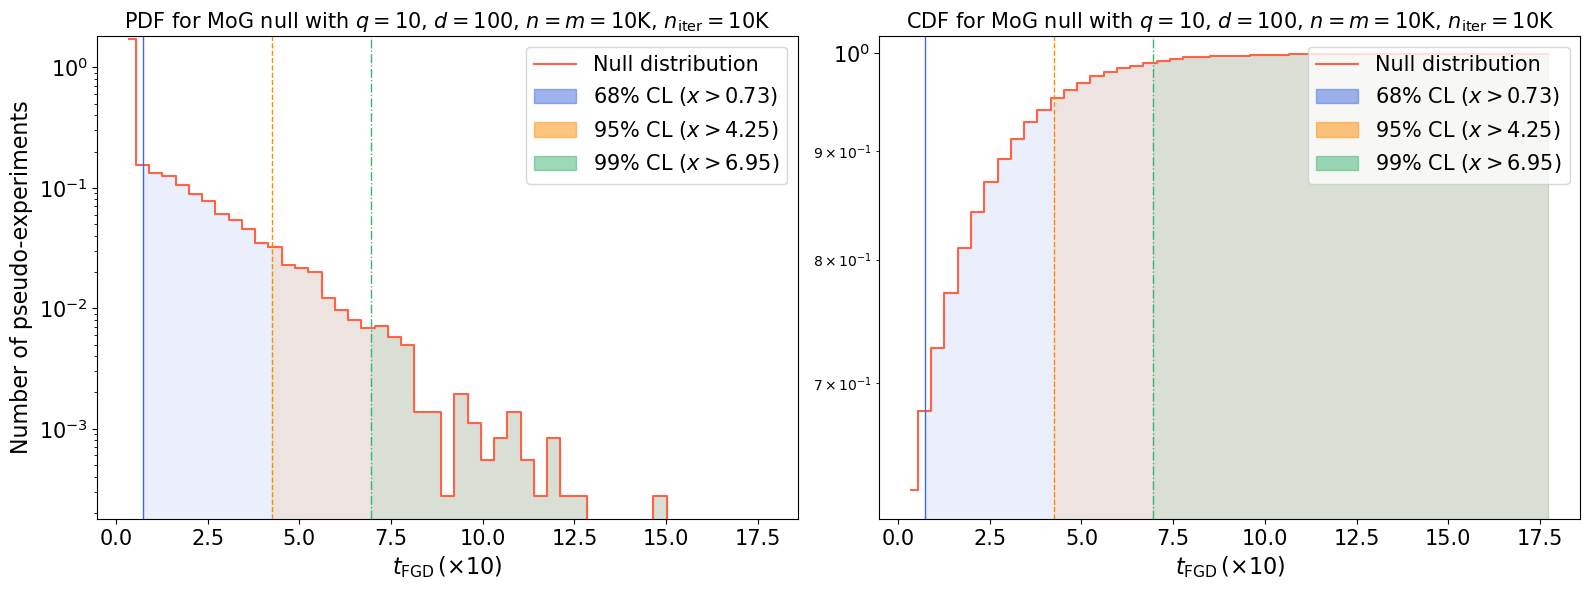

Time elapsed: 0.8690340050961822 seconds.
mu = 5.9402579030847844e-05 +/- 0.007628791703319754
sigma = 0.8734295451448705 +/- 0.009105358567438687
68%CL = 0.24684263086464853, 95%CL = 1.6439586624787808, 99%CL = 2.7744840692162143
mu = 5.9402579030847844e-05 +/- 0.007628791703319754
sigma = 0.8734295451448705 +/- 0.009105358567438687


/tmp/ipykernel_2826380/2309989867.py:86: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(current_ylim0)
/tmp/ipykernel_2826380/2309989867.py:88: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend0.legendHandles[-3:]:
/tmp/ipykernel_2826380/2309989867.py:123: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1].set_ylim(current_ylim1)
/tmp/ipykernel_2826380/2309989867.py:129: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend1.legendHandles[-3:]:


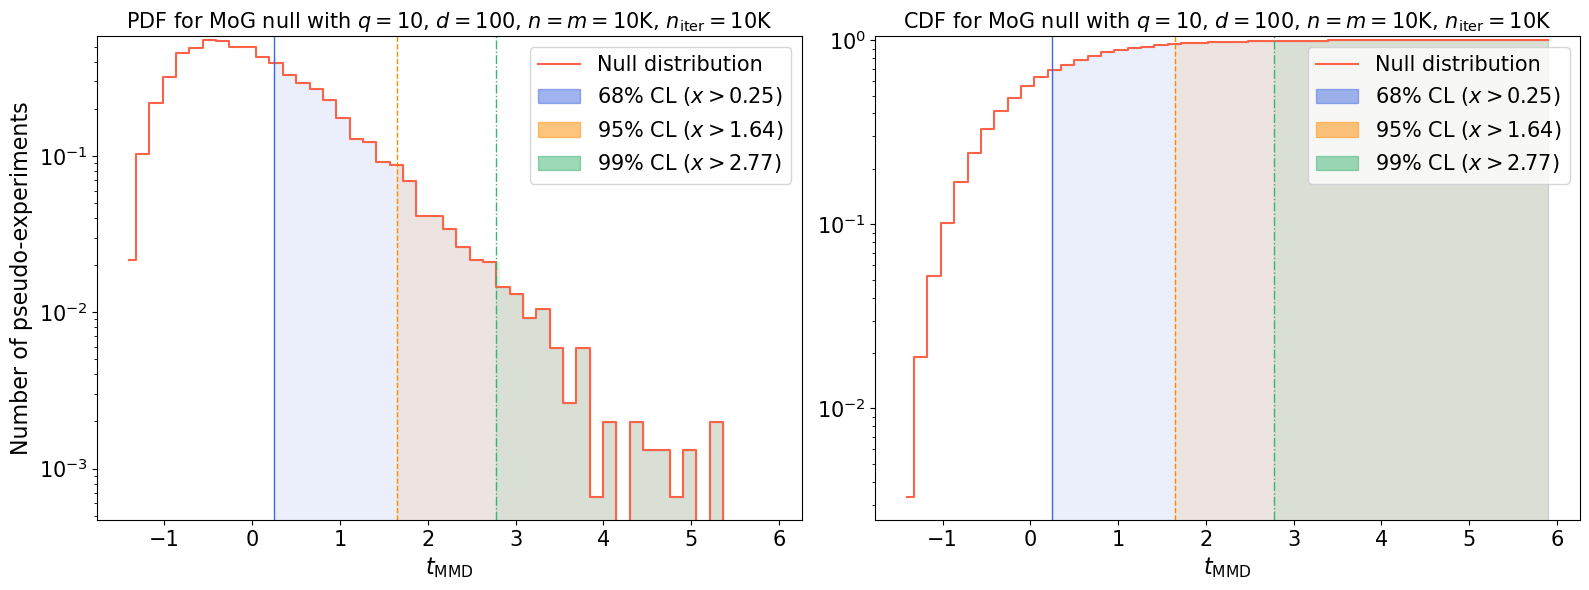

Time elapsed: 0.5899497591890395 seconds.
mu = 0.8641409322935233 +/- 0.00014674241604892957
sigma = 0.12113728412381118 +/- 0.0009810742216711094
68%CL = 0.9123097767095693, 95%CL = 1.080035046430143, 99%CL = 1.1955053942298108
mu = 0.8641409322935233 +/- 0.00014674241604892957
sigma = 0.12113728412381118 +/- 0.0009810742216711094


/tmp/ipykernel_2826380/2309989867.py:86: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(current_ylim0)
/tmp/ipykernel_2826380/2309989867.py:88: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend0.legendHandles[-3:]:
/tmp/ipykernel_2826380/2309989867.py:123: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1].set_ylim(current_ylim1)
/tmp/ipykernel_2826380/2309989867.py:129: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend1.legendHandles[-3:]:


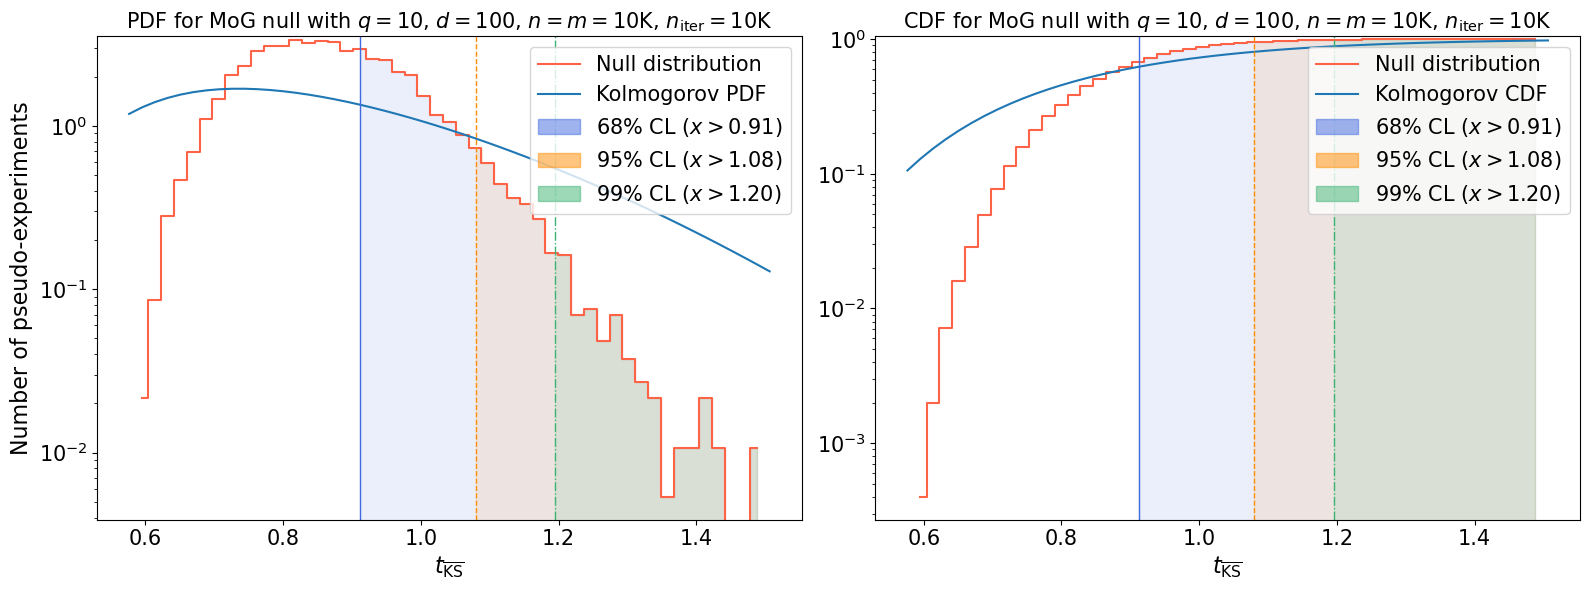

Time elapsed: 0.8197276128921658 seconds.
mu = 0.8654108027841044 +/- 0.00013601742110535907
sigma = 0.11662650689502754 +/- 0.0009388596610425206
68%CL = 0.9096933635742858, 95%CL = 1.075438940502564, 99%CL = 1.1947278902419063
mu = 0.8654108027841044 +/- 0.00013601742110535907
sigma = 0.11662650689502754 +/- 0.0009388596610425206


/tmp/ipykernel_2826380/2309989867.py:86: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(current_ylim0)
/tmp/ipykernel_2826380/2309989867.py:88: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend0.legendHandles[-3:]:
/tmp/ipykernel_2826380/2309989867.py:123: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1].set_ylim(current_ylim1)
/tmp/ipykernel_2826380/2309989867.py:129: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend1.legendHandles[-3:]:


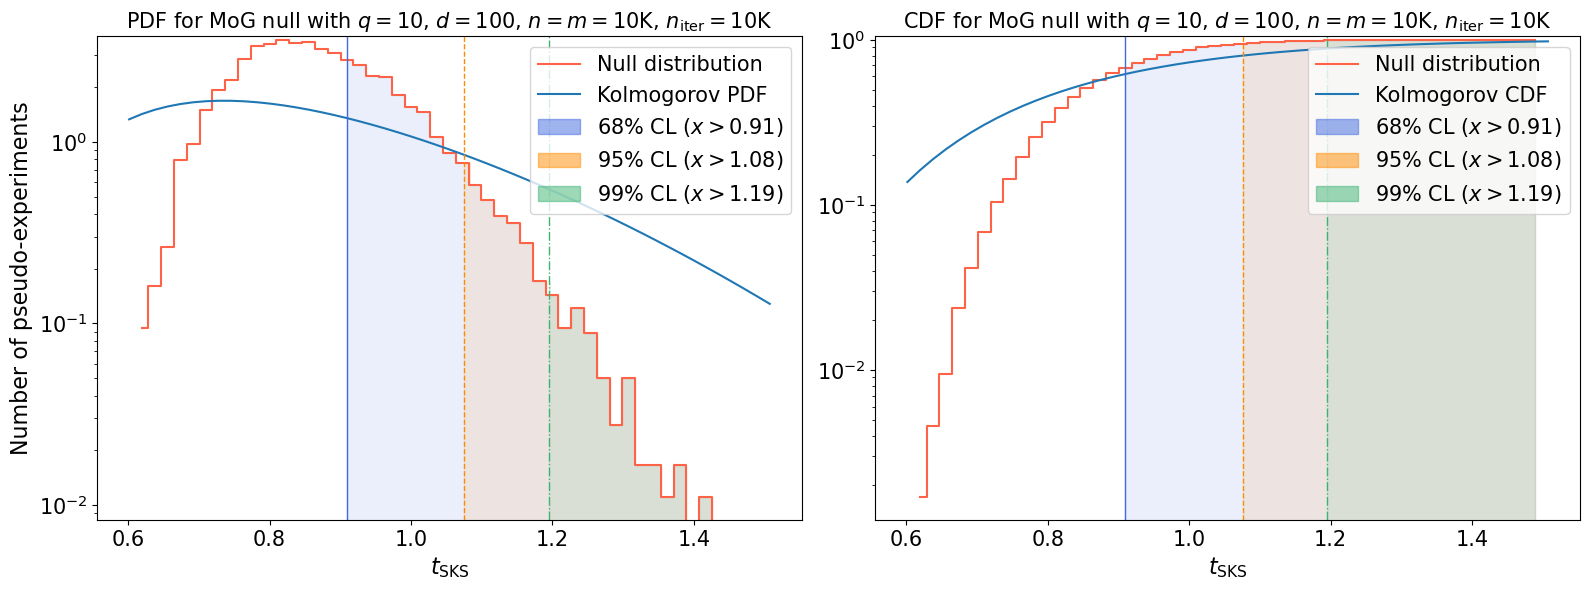

Time elapsed: 0.7183777780737728 seconds.
mu = 0.32334375795994746 +/- 4.47700032200621e-05
sigma = 0.06691039023953013 +/- 0.0005155858100974447
68%CL = 0.3490127174390403, 95%CL = 0.44486819653933474, 99%CL = 0.5089047572892257
mu = 0.32334375795994746 +/- 4.47700032200621e-05
sigma = 0.06691039023953013 +/- 0.0005155858100974447


/tmp/ipykernel_2826380/2309989867.py:86: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(current_ylim0)
/tmp/ipykernel_2826380/2309989867.py:88: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend0.legendHandles[-3:]:
/tmp/ipykernel_2826380/2309989867.py:123: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1].set_ylim(current_ylim1)
/tmp/ipykernel_2826380/2309989867.py:129: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend1.legendHandles[-3:]:


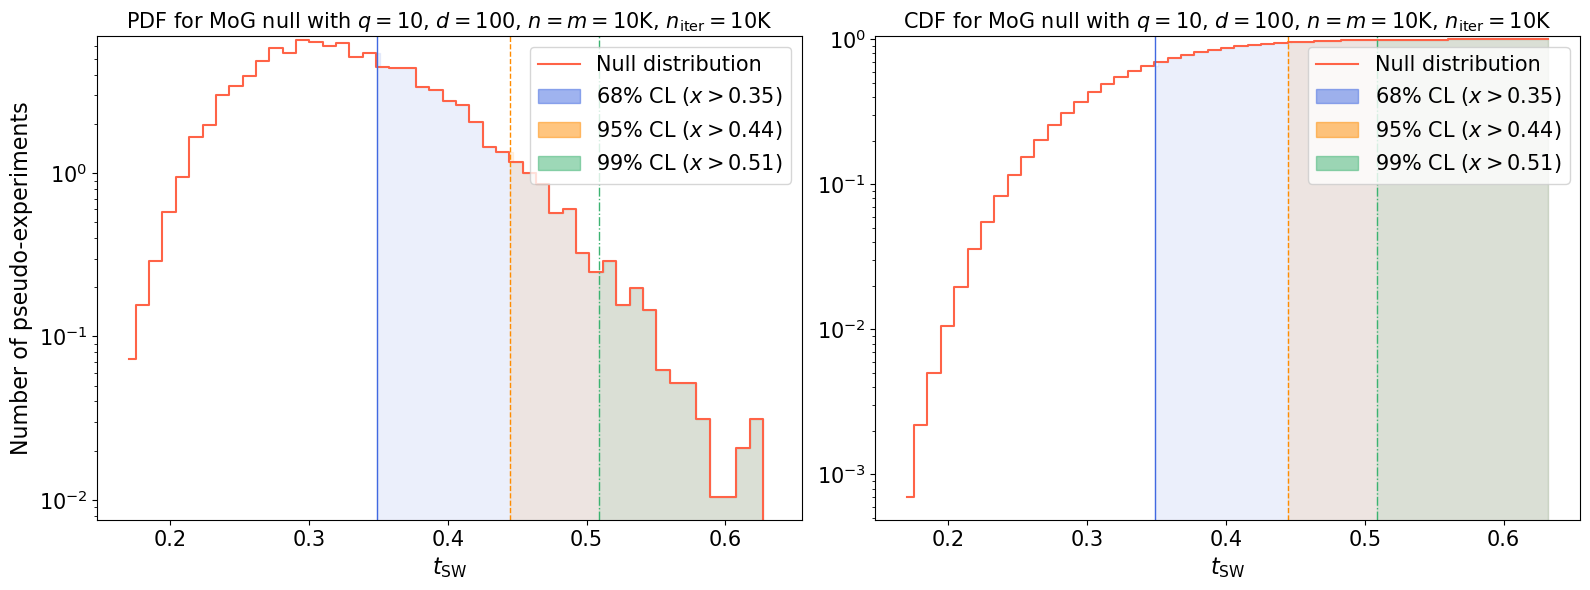

Time elapsed: 0.5875780170317739 seconds.


,name,object_name,class_name,kwargs,result_key,scale_func,scale_func_string,test_config,max_vectorize,latex,null_file,thresholds,null_figure
0,fgd,FGDMetric,GMetrics.FGDMetric,"{'num_batches': 20, 'num_points': 10, 'normali...",metric_list,<function <lambda> at 0x7f1cfc136b00>,"lambda ns, ndims: 1","{'niter': 10000, 'batch_size_test': 10000, 'ba...",100,$t_{\mathrm{FGD}}$,results/100D_mixture/100D_10K/null_hypothesis/...,"[[0.68, [6800, 3199], 0.07318253682191163], [0...",results/100D_mixture/100D_10K/null_hypothesis/...
1,mmd,MMDMetric,GMetrics.MMDMetric,"{'degree': 4, 'block_size': 10000, 'normalise'...",metric_list,<function <lambda> at 0x7f1cfc134ca0>,"lambda ns, ndims: 1","{'niter': 10000, 'batch_size_test': 10000, 'ba...",2,$t_{\mathrm{MMD}}$,results/100D_mixture/100D_10K/null_hypothesis/...,"[[0.68, [6800, 3199], 0.24684263086464853], [0...",results/100D_mixture/100D_10K/null_hypothesis/...
2,ks,KSTest,GMetrics.KSTest,{},statistic_means,<function <lambda> at 0x7f1cfc136b90>,"lambda ns, _: np.sqrt(ns)","{'niter': 10000, 'batch_size_test': 10000, 'ba...",10000,$t_{\overline{\mathrm{KS}}}$,results/100D_mixture/100D_10K/null_hypothesis/...,"[[0.68, [6800, 3199], 0.9123097767095693], [0....",results/100D_mixture/100D_10K/null_hypothesis/...
3,sks,SKSTest,GMetrics.SKSTest,"{'nslices': 100, 'seed_slicing': 0}",metric_means,<function <lambda> at 0x7f1cfc136c20>,"lambda ns, _: np.sqrt(ns)","{'niter': 10000, 'batch_size_test': 10000, 'ba...",200,$t_{\mathrm{SKS}}$,results/100D_mixture/100D_10K/null_hypothesis/...,"[[0.68, [6800, 3199], 0.9096933635742858], [0....",results/100D_mixture/100D_10K/null_hypothesis/...
4,swd,SWDMetric,GMetrics.SWDMetric,"{'nslices': 100, 'seed_slicing': 0}",metric_means,<function <lambda> at 0x7f1cfc136cb0>,"lambda ns, ndims: np.sqrt(ns/ndims)","{'niter': 10000, 'batch_size_test': 10000, 'ba...",200,$t_{\mathrm{SW}}$,results/100D_mixture/100D_10K/null_hypothesis/...,"[[0.68, [6800, 3199], 0.3490127174390403], [0....",results/100D_mixture/100D_10K/null_hypothesis/...
5,lr,LRMetric,GMetrics.LRMetric,{'null_test': True},lik_ratio_norm_list,<function <lambda> at 0x7f1cfc136d40>,"lambda ns, ndims: np.sqrt(ns)","{'niter': 10000, 'batch_size_test': 10000, 'ba...",50,$t_{\mathrm{LLR}}$,results/100D_mixture/100D_10K/null_hypothesis/...,[],NaN


In [ ]:
for metric in list(metrics_config[unique_key].values())[:-1]:
    name = metric["name"]
    name_cap = name.upper()
    latex = metric["latex"]
    obj = eval(metric["object_name"])
    result_key = metric["result_key"]
    scale_func = metric["scale_func"]
    figure_file = metric["null_file"].replace("json","pdf")
    thresholds = metric["thresholds"]

    start = timer()
    
    nsamples = obj.Inputs.batch_size_test
    niter = obj.Inputs.niter
    ns = nsamples**2 /(2*nsamples)
    dist_null = np.array(obj.Results[-1].result_value[result_key])*scale_func(ns, ndims)
    if "FGD" in latex:
        latex = r"$t_{\mathrm{FGD}}\,(\times 10)$"
        dist_null = dist_null * 10
    #elif "MMD" in latex:
    #    latex = r"$t_{\mathrm{MMD}}\,(\times 10^{-2})$"
    #    dist_null = dist_null / 100
    
    scale = 'log'
    num_bins = 50  # number of bins|
    
    mu, deltamu, sigma, deltasigma = (np.mean(dist_null), se_mean(dist_null), np.std(dist_null), se_std(dist_null))
    sigma_68, sigma_95, sigma_99 = [np.sort(dist_null)[int(len(dist_null)*cl)] for cl in [0.68, 0.95, 0.99]]
    print(f"mu = {mu} +/- {deltamu}")
    print(f"sigma = {sigma} +/- {deltasigma}")
    print(f"68%CL = {sigma_68}, 95%CL = {sigma_95}, 99%CL = {sigma_99}")
    
    print("mu =", mu, "+/-", deltamu)
    print("sigma =", sigma, "+/-", deltasigma)
    
    min_x, max_x = min(dist_null), max(dist_null) # lower and upper limit of the binning
    x = np.linspace(min_x, max_x, num_bins + 1)
    counts, bin_edges = np.histogram(dist_null, bins=x, density=True)
    cum_counts = np.cumsum(counts)/np.sum(counts)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Only if metric is KS-derived plot the theoretical distribution
    if "ks" in name:
        # Calculate the theoretical PDF and CDF of the KS distribution for each x value
        theoretical_pdf_ks = kstwobign.pdf(x)
        theoretical_cdf_ks = kstwobign.cdf(x)

        # Empirical SKS Normal
        empirical_pdf_norm = norm.pdf(x, loc=kstwobign.mean(), scale=kstwobign.std())
        empirical_cdf_norm = norm.cdf(x, loc=kstwobign.mean(), scale=kstwobign.std())

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    dash_styles = ['-', '--', '-.']
    colors = ["royalblue", "darkorange", "mediumseagreen"]
    
    # Create step plot
    step_edges = np.convolve(bin_centers, [0.5, 0.5], 'valid')
    step_counts = counts[:-1]  # assuming counts is one element longer than step_edges

    ax[0].step(step_edges, step_counts, where='mid', linestyle='-', color = "tomato", label = "Null distribution")
    current_ylim0 = ax[0].get_ylim()
    if "ks" in name:
        ax[0].plot(x, theoretical_pdf_ks, label="Kolmogorov PDF")
    ax[0].set_yscale(scale)
    ax[0].set_xlabel(r"%s"%latex, fontsize=16)
    ax[0].set_ylabel('Number of pseudo-experiments', fontsize=16)
    ax[0].set_title('PDF for MoG null with $q = '+str(ncomp)+'$, $d = '+str(ndims)+'$, $n=m='+str(int(nsamples/1000))+'$K, $n_{\mathrm{iter}} = '+str(int(niter/1000))+'$K', fontsize=15)
    ax[0].tick_params(axis='x', labelsize=15)  # Set x-axis tick label size
    ax[0].tick_params(axis='y', labelsize=15)  # Set y-axis tick label size
    
    for i, threshold in enumerate(thresholds):
        confidence_level, _, threshold_value = threshold
        if "FGD" in latex:
            threshold_value = threshold_value * 10
        #elif "MMD" in latex:
        #    threshold_value = threshold_value / 100
        start_index = np.searchsorted(step_edges, threshold_value, side="right") - 1
        start_index = max(start_index, 0)
        fill_x_range = np.concatenate([[threshold_value], step_edges[start_index+1:]])
        fill_y_values = step_counts[start_index:]
        if len(fill_x_range) > 1 and len(fill_y_values) > 0:
            ax[0].fill_between(fill_x_range, 0, fill_y_values, color=colors[i], alpha=0.1, step='mid', label=f"{int(confidence_level * 100)}% CL ($x>{format(threshold_value, '.2f')}   $)")
        ax[0].axvline(x=threshold_value, linestyle=dash_styles[i], color=colors[i], linewidth=1)

    ax[0].set_ylim(current_ylim0)  
    legend0 = ax[0].legend(loc='upper right', fontsize=15)
    for handle in legend0.legendHandles[-3:]:
        handle.set_alpha(0.5)  # Set to desired alpha value
    
    # Create step plot
    step_edges = np.convolve(bin_centers, [0.5, 0.5], 'valid')
    step_counts = cum_counts[:-1]  # assuming counts is one element longer than step_edges
    
    ax[1].step(step_edges, step_counts, where='mid', linestyle='-', color = "tomato", label = "Null distribution")
    #ax[1].plot(bin_centers, cum_counts, linestyle = '-', color = "tomato", label = "Null distribution", drawstyle='steps-mid')
    current_ylim1 = ax[1].get_ylim()
    if "ks" in name:
        ax[1].plot(x, theoretical_cdf_ks, label="Kolmogorov CDF")
    #for i, threshold in enumerate(thresholds):
    #    confidence_level, _, threshold_value = threshold
    #    ax[1].axhline(y=confidence_level, color=colors[i], linestyle=dash_styles[i], linewidth=0.5, alpha=1)
    ax[1].set_yscale(scale)
    ax[1].set_xlabel(r"%s"%latex, fontsize=16)
    ax[1].set_title('CDF for MoG null with $q = '+str(ncomp)+'$, $d = '+str(ndims)+'$, $n=m='+str(int(nsamples/1000))+'$K, $n_{\mathrm{iter}} = '+str(int(niter/1000))+'$K', fontsize=15)
    ax[1].tick_params(axis='x', labelsize=15)  # Set x-axis tick label size
    ax[1].tick_params(axis='y', labelsize=15)  # Set y-axis tick label size
    
    for i, threshold in enumerate(thresholds):
        confidence_level, _, threshold_value = threshold
        if "FGD" in latex:
            threshold_value = threshold_value * 10
        #elif "MMD" in latex:
        #    threshold_value = threshold_value / 100
        start_index = np.searchsorted(step_edges, threshold_value, side="right") - 1
        start_index = max(start_index, 0)
        fill_x_range = np.concatenate([[threshold_value], step_edges[start_index+1:]])
        fill_y_values = step_counts[start_index:]
        if len(fill_x_range) > 1 and len(fill_y_values) > 0:
            ax[1].fill_between(fill_x_range, 0, fill_y_values, color=colors[i], alpha=0.1, step='mid', label=f"{int(confidence_level * 100)}% CL ($x>{format(threshold_value, '.2f')}   $)")
        ax[1].axvline(x=threshold_value, linestyle=dash_styles[i], color=colors[i], linewidth=1)
    
    ax[1].set_ylim(current_ylim1)  
    #for i, threshold in enumerate(thresholds):
    #    confidence, _, value = threshold
    #    ax[1].axvline(x=value, color=colors[i], linestyle=dash_styles[i], alpha=1, label=f"{int(confidence_level * 100)} CL% ($x>{format(threshold_value,'.2f')}$)")
    
    legend1 = ax[1].legend(loc='upper right', fontsize=15)
    for handle in legend1.legendHandles[-3:]:
        handle.set_alpha(0.5)  # Set to desired alpha value
    
    plt.subplots_adjust(wspace=0.1)  # Adjust this value to your liking
    plt.tight_layout()
    plt.savefig(figure_file)
    plt.show()
    plt.close()
    
    metric.update({"null_figure": figure_file})

    end = timer()
    print("Time elapsed:", end-start, "seconds.")

GMetrics.utils.save_update_metrics_config(metrics_config = metrics_config, metrics_config_file = metrics_config_file) # type: ignore

## Alternative hypotheses and results

### Scan and exclusion limits (bisection method)

In [ ]:
if test_config_null["use_tf"]:
    dtype = getattr(tf, test_config_null["dtype_input"])
else:
    
    dtype = np.dtype(test_config_null["dtype_input"])
test_kwargs = {"niter_null": niter,
               "niter_alt": 100,
               "batch_size_test": test_config_null["batch_size_test"],
               "batch_size_gen": test_config_null["batch_size_gen"],
               "small_sample_threshold": test_config_null["small_sample_threshold"],
               "dtype_input": dtype,
               "seed_input": test_config_null["seed"],
               "use_tf": test_config_null["use_tf"],
               "mirror_strategy": test_config_null["mirror_strategy"],
               "verbose": False}

In [ ]:
file_path = os.path.join(model_dir, "exclusion_limits.json")
if os.path.exists(file_path):
    try:
        with open(file_path, "r") as file:
            existing_data = json.load(file)
    except json.JSONDecodeError:
        existing_data = {}
else:
    existing_data = {}
    
# Sort the dictionary by keys
existing_data = dict(sorted(existing_data.items()))

# Save the sorted dictionary back to a JSON file
with open(file_path, 'w') as f:
    json.dump(existing_data, f, cls=GMetrics.utils.CustomEncoder, indent=4) # type: ignore

In [ ]:
deformations = ["mean", "cov_diag", "cov_off_diag", "power_abs_up", "power_abs_down", "random_normal", "random_uniform"]
bounds = ["upper", "central", "lower"]
global_results = {}

for metric_config in list(metrics_config[unique_key].values())[:-1]:
    for deformation in deformations:
        eps_max = 2.
        for bound in bounds:
            try:
                result = {k: v for k, v in {k: v for k, v in existing_data.items() if v["null_config"]["name"] == metric_config["name"] and v["deformation"] == deformation and v["bound"] == bound}.items() if v["exclusion_list"] != []}
            except:
                result = {}
            if result == {}:
                print(f"Computing {bound} bounds for {metric_config['name']} with {deformation} deformation.")
                result = compute_exclusion_bisection(dist_1,
                                                     metric_config = metric_config,
                                                     test_kwargs = test_kwargs,
                                                     model_dir = model_dir,
                                                     deformation = deformation,
                                                     seed_dist = 0,
                                                     x_tol = 0.01,
                                                     fn_tol = 0.05,
                                                     bound = bound,
                                                     eps_min = 0.,
                                                     eps_max = eps_max,
                                                     max_iterations = 50,
                                                     save = True,
                                                     filename = "exclusion_limits.json",
                                                     verbose = True)
                eps_max = list(result.values())[0]["exclusion_list"][-1][3]
            else:
                print(f"{bound.capitalize()} bounds for {metric_config['name']} with {deformation} deformation already loaded.")
            global_results.update(result)
print(global_results.keys())

Upper bounds for fgd with mean deformation already loaded.
Central bounds for fgd with mean deformation already loaded.
Lower bounds for fgd with mean deformation already loaded.
Upper bounds for fgd with cov_diag deformation already loaded.
Central bounds for fgd with cov_diag deformation already loaded.
Lower bounds for fgd with cov_diag deformation already loaded.
Upper bounds for fgd with cov_off_diag deformation already loaded.
Central bounds for fgd with cov_off_diag deformation already loaded.
Lower bounds for fgd with cov_off_diag deformation already loaded.
Upper bounds for fgd with power_abs_up deformation already loaded.
Central bounds for fgd with power_abs_up deformation already loaded.
Lower bounds for fgd with power_abs_up deformation already loaded.
Upper bounds for fgd with power_abs_down deformation already loaded.
Central bounds for fgd with power_abs_down deformation already loaded.
Lower bounds for fgd with power_abs_down deformation already loaded.
Upper bounds fo

### Likelihood-ratio test

In [ ]:
if test_config_null["use_tf"]:
    dtype = getattr(tf, test_config_null["dtype_input"])
else:
    dtype = np.dtype(test_config_null["dtype_input"])
test_kwargs = {"niter_null": niter,
               "niter_alt": 100,
               "batch_size_test": test_config_null["batch_size_test"],
               "batch_size_gen": test_config_null["batch_size_gen"],
               "small_sample_threshold": test_config_null["small_sample_threshold"],
               "dtype_input": dtype,
               "seed_input": test_config_null["seed"],
               "use_tf": test_config_null["use_tf"],
               "mirror_strategy": test_config_null["mirror_strategy"],
               "verbose": True}
metrics_config[unique_key]["lr"]['kwargs']["verbose"] = True

In [ ]:
deformations = ["mean", "cov_diag", "power_abs_up", "power_abs_down"]
eps_max_def = []
bounds = ["upper", "central", "lower"]

for deformation in deformations:
    eps_max = 2.
    for bound in bounds:
        try:
            result = {k: v for k, v in existing_data.items() if v["null_config"]["name"] == "lr" and v["deformation"] == deformation and v["bound"] == bound}
        except:
            result = {}
        if result == {}:
            print(f"Computing {bound} bounds for lr with {deformation} deformation.")
            result = compute_exclusion_LR_bisection(dist_1,
                                                    metric_config = metrics_config[unique_key]["lr"],
                                                    test_kwargs = test_kwargs,
                                                    model_dir = model_dir,
                                                    cl_list = [0.95, 0.99],
                                                    deformation = deformation,
                                                    seed_dist = 0,
                                                    x_tol = 0.01,
                                                    fn_tol = 0.05,
                                                    bound = bound,
                                                    eps_min = 0.,
                                                    eps_max = eps_max,
                                                    max_iterations = 50,
                                                    save = True,
                                                    filename = "exclusion_limits.json",
                                                    verbose = True)
            eps_max = list(result.values())[0]["exclusion_list"][-1][3]
        else:
            print(f"{bound.capitalize()} bounds for lr with {deformation} deformation already loaded.")
        global_results.update(result)
print(global_results.keys())

Upper bounds for lr with mean deformation already loaded.
Central bounds for lr with mean deformation already loaded.
Lower bounds for lr with mean deformation already loaded.
Upper bounds for lr with cov_diag deformation already loaded.
Central bounds for lr with cov_diag deformation already loaded.
Lower bounds for lr with cov_diag deformation already loaded.
Upper bounds for lr with power_abs_up deformation already loaded.
Central bounds for lr with power_abs_up deformation already loaded.
Lower bounds for lr with power_abs_up deformation already loaded.
Upper bounds for lr with power_abs_down deformation already loaded.
Central bounds for lr with power_abs_down deformation already loaded.
Lower bounds for lr with power_abs_down deformation already loaded.
dict_keys(['fgd_mean_upper_2024-05-20T20:56:01.873647', 'fgd_mean_central_2024-05-20T21:14:59.553903', 'fgd_mean_lower_2024-05-20T21:27:50.310754', 'fgd_cov_diag_upper_2024-05-20T21:41:17.730985', 'fgd_cov_diag_central_2024-05-20T

## Show and save results

In [ ]:
import notebooks.shared as shared

In [ ]:
results_df, times_df = shared.generate_result_dataframe(global_results, null_times)

Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: fgd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: mmd
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: ks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: sks
Metric: swd
M

In [ ]:
results_df_mean, results_df_cov_diag, results_df_cov_off_diag, results_df_power_abs_up, results_df_power_abs_down, results_df_random_normal, results_df_random_uniform = shared.get_individual_dfs(results_df, show = True)

,Statistic,$\epsilon^{\mu}_{95\%\mathrm{CL}}$,$\epsilon^{\mu}_{99\%\mathrm{CL}}$,$t^{\mu}$ (s)
34,swd,$0.09504_{-0.028}^{+0.024}$,$0.12338_{-0.024}^{+0.023}$,$648$
9,ks,$0.00787_{-0.0029}^{+0.0031}$,$0.01207_{-0.0032}^{+0.0034}$,$1244$
27,sks,$0.07672_{-0.021}^{+0.018}$,$0.10153_{-0.018}^{+0.016}$,$688$
2,fgd,$0.13134_{-0.034}^{+0.032}$,$0.16599_{-0.028}^{+0.028}$,$2715$
20,mmd,$0.10962_{-0.035}^{+0.028}$,$0.14183_{-0.026}^{+0.023}$,$1350$
15,lr,$9e-05_{-6e-05}^{+6e-05}$,$0.00012_{-6e-05}^{+6e-05}$,$3225$


,Statistic,$\epsilon^{\Sigma_{ii}}_{95\%\mathrm{CL}}$,$\epsilon^{\Sigma_{ii}}_{99\%\mathrm{CL}}$,$t^{\Sigma_{ii}}$ (s)
32,swd,$0.03044_{-0.0084}^{+0.0066}$,$0.03963_{-0.0067}^{+0.0061}$,$711$
7,ks,$0.00217_{-0.00099}^{+0.0011}$,$0.00375_{-0.0012}^{+0.0011}$,$1389$
25,sks,$0.02687_{-0.0056}^{+0.0041}$,$0.0345_{-0.004}^{+0.0036}$,$736$
0,fgd,$0.04142_{-0.01}^{+0.0081}$,$0.05232_{-0.0074}^{+0.0067}$,$2955$
18,mmd,$0.02117_{-0.0078}^{+0.007}$,$0.02757_{-0.0064}^{+0.0062}$,$1536$
14,lr,$2e-05_{-1e-05}^{+1e-05}$,$2e-05_{-1e-05}^{+2e-05}$,$3499$


,Statistic,$\epsilon^{\Sigma_{i\neq j}}_{95\%\mathrm{CL}}$,$\epsilon^{\Sigma_{i\neq j}}_{99\%\mathrm{CL}}$,$t^{\Sigma_{i\neq j}}$ (s)
33,swd,$0.05622_{-0.015}^{+0.011}$,$0.07365_{-0.011}^{+0.0088}$,$3594$
8,ks,$1.00157_{-0.00012}^{+0.00038}$,$1.00402_{-0.0018}^{+0.00037}$,$10395$
26,sks,$0.0607_{-0.015}^{+0.013}$,$0.07996_{-0.013}^{+0.011}$,$4297$
1,fgd,$0.00958_{-0.0026}^{+0.0021}$,$0.01249_{-0.0019}^{+0.0018}$,$7784$
19,mmd,$0.03968_{-0.012}^{+0.01}$,$0.05143_{-0.0095}^{+0.0089}$,$5795$


,Statistic,$\epsilon^{\rm{pow}_{+}}_{95\%\mathrm{CL}}$,$\epsilon^{\rm{pow}_{+}}_{99\%\mathrm{CL}}$,$t^{\rm{pow}_{+}}$ (s)
36,swd,$0.01206_{-0.0033}^{+0.0028}$,$0.01579_{-0.0028}^{+0.0023}$,$730$
11,ks,$0.00084_{-0.00041}^{+0.00043}$,$0.00144_{-0.00045}^{+0.00041}$,$1467$
29,sks,$0.01088_{-0.0021}^{+0.0016}$,$0.0139_{-0.0015}^{+0.0013}$,$773$
4,fgd,$0.01638_{-0.0039}^{+0.0032}$,$0.02069_{-0.003}^{+0.0027}$,$2488$
22,mmd,$0.00761_{-0.0028}^{+0.0026}$,$0.00988_{-0.0023}^{+0.0023}$,$1238$
17,lr,$1e-05_{-1e-05}^{+0}$,$1e-05_{-1e-05}^{+0}$,$3842$


,Statistic,$\epsilon^{\rm{pow}_{-}}_{95\%\mathrm{CL}}$,$\epsilon^{\rm{pow}_{-}}_{99\%\mathrm{CL}}$,$t^{\rm{pow}_{-}}$ (s)
35,swd,$0.01253_{-0.0032}^{+5}$,$0.0164_{-0.0026}^{+5}$,$653$
10,ks,$0.00086_{-0.00043}^{+0.00044}$,$0.00147_{-0.00047}^{+0.00042}$,$1542$
28,sks,$0.01077_{-0.0021}^{+0.0016}$,$0.01376_{-0.0015}^{+0.0013}$,$786$
3,fgd,$0.01685_{-0.0038}^{+0.0032}$,$0.02139_{-0.0032}^{+0.0026}$,$3221$
21,mmd,$0.00834_{-0.0025}^{+0.0023}$,$0.01083_{-0.0021}^{+0.002}$,$1257$
16,lr,$1e-05_{-1e-05}^{+0}$,$1e-05_{-1e-05}^{+0}$,$4903$


,Statistic,$\epsilon^{\mathcal{N}}_{95\%\mathrm{CL}}$,$\epsilon^{\mathcal{N}}_{99\%\mathrm{CL}}$,$t^{\mathcal{N}}$ (s)
37,swd,$0.32495_{-0.046}^{+0.033}$,$0.37663_{-0.032}^{+0.025}$,$617$
12,ks,$0.02563_{-0.0097}^{+0.0081}$,$0.03668_{-0.008}^{+0.0078}$,$652$
30,sks,$0.27956_{-0.043}^{+0.034}$,$0.32856_{-0.033}^{+0.027}$,$657$
5,fgd,$0.28803_{-0.038}^{+0.027}$,$0.32529_{-0.025}^{+0.021}$,$2636$
23,mmd,$1.17867_{-0.19}^{+0.13}$,$1.33971_{-0.12}^{+0.09}$,$731$


,Statistic,$\epsilon^{\mathcal{U}}_{95\%\mathrm{CL}}$,$\epsilon^{\mathcal{U}}_{99\%\mathrm{CL}}$,$t^{\mathcal{U}}$ (s)
38,swd,$0.56347_{-0.083}^{+0.054}$,$0.65308_{-0.056}^{+0.044}$,$588$
13,ks,$0.03885_{-0.015}^{+0.012}$,$0.0555_{-0.012}^{+0.011}$,$644$
31,sks,$0.48383_{-0.074}^{+0.061}$,$0.56865_{-0.057}^{+0.048}$,$631$
6,fgd,$0.49924_{-0.066}^{+0.046}$,$0.56381_{-0.047}^{+0.036}$,$2515$
24,mmd,$2.02548_{-0.32}^{+0.23}$,$2.31727_{-0.2}^{+0.16}$,$1113$


In [ ]:
sorted_df_mean, sorted_df_cov_diag, sorted_df_cov_off_diag, sorted_df_power_abs_up, sorted_df_power_abs_down, sorted_df_random_normal, sorted_df_random_uniform = shared.get_sorted_dfs(results_df, show = True)

,Statistic,Deformation,$N$,$n=m$,$n_{\mathrm{iter}}$,$\epsilon^{\mu}_{95\%\mathrm{CL}}$,$\epsilon^{\mu}_{99\%\mathrm{CL}}$,$t^{\mu}$ (s),95%CL,99%CL,time
15,lr,mean,100,10000,10000,$9e-05_{-6e-05}^{+6e-05}$,$0.00012_{-6e-05}^{+6e-05}$,$3225$,"[3e-05, 9e-05, 0.00015]","[6e-05, 0.00012, 0.00018]","[1452.8160479199723, 828.7335907989764, 943.75..."
9,ks,mean,100,10000,10000,$0.00787_{-0.0029}^{+0.0031}$,$0.01207_{-0.0032}^{+0.0034}$,$1244$,"[0.00502, 0.00787, 0.01095]","[0.00885, 0.01207, 0.01544]","[626.833171566017, 298.266290219035, 319.80659..."
27,sks,mean,100,10000,10000,$0.07672_{-0.021}^{+0.018}$,$0.10153_{-0.018}^{+0.016}$,$688$,"[0.05612, 0.07672, 0.09491]","[0.08344, 0.10153, 0.11796]","[325.8986203240347, 179.8400951740332, 182.901..."
34,swd,mean,100,10000,10000,$0.09504_{-0.028}^{+0.024}$,$0.12338_{-0.024}^{+0.023}$,$648$,"[0.06723, 0.09504, 0.11932]","[0.09926, 0.12338, 0.14613]","[301.7312141380389, 175.57618913502665, 171.41..."
20,mmd,mean,100,10000,10000,$0.10962_{-0.035}^{+0.028}$,$0.14183_{-0.026}^{+0.023}$,$1350$,"[0.07507, 0.10962, 0.13721]","[0.11627, 0.14183, 0.16459]","[554.4668482550187, 399.31127638404723, 396.47..."
2,fgd,mean,100,10000,10000,$0.13134_{-0.034}^{+0.032}$,$0.16599_{-0.028}^{+0.028}$,$2715$,"[0.09758, 0.13134, 0.16357]","[0.13766, 0.16599, 0.1938]","[1137.666811497009, 770.7390508560347, 807.395..."


,Statistic,$\epsilon^{\mu}_{95\%\mathrm{CL}}$,$\epsilon^{\mu}_{99\%\mathrm{CL}}$,$t^{\mu}$ (s)
15,lr,$9e-05_{-6e-05}^{+6e-05}$,$0.00012_{-6e-05}^{+6e-05}$,$3225$
9,ks,$0.00787_{-0.0029}^{+0.0031}$,$0.01207_{-0.0032}^{+0.0034}$,$1244$
27,sks,$0.07672_{-0.021}^{+0.018}$,$0.10153_{-0.018}^{+0.016}$,$688$
34,swd,$0.09504_{-0.028}^{+0.024}$,$0.12338_{-0.024}^{+0.023}$,$648$
20,mmd,$0.10962_{-0.035}^{+0.028}$,$0.14183_{-0.026}^{+0.023}$,$1350$
2,fgd,$0.13134_{-0.034}^{+0.032}$,$0.16599_{-0.028}^{+0.028}$,$2715$


,Statistic,Deformation,$N$,$n=m$,$n_{\mathrm{iter}}$,$\epsilon^{\Sigma_{ii}}_{95\%\mathrm{CL}}$,$\epsilon^{\Sigma_{ii}}_{99\%\mathrm{CL}}$,$t^{\Sigma_{ii}}$ (s),95%CL,99%CL,time
14,lr,cov_diag,100,10000,10000,$2e-05_{-1e-05}^{+1e-05}$,$2e-05_{-1e-05}^{+2e-05}$,$3499$,"[1e-05, 2e-05, 3e-05]","[1e-05, 2e-05, 4e-05]","[1690.524092015985, 846.3883342450135, 962.385..."
7,ks,cov_diag,100,10000,10000,$0.00217_{-0.00099}^{+0.0011}$,$0.00375_{-0.0012}^{+0.0011}$,$1389$,"[0.00118, 0.00217, 0.00331]","[0.00256, 0.00375, 0.00482]","[710.9652191640344, 330.3927075730171, 348.242..."
18,mmd,cov_diag,100,10000,10000,$0.02117_{-0.0078}^{+0.007}$,$0.02757_{-0.0064}^{+0.0062}$,$1536$,"[0.01341, 0.02117, 0.0282]","[0.02121, 0.02757, 0.03377]","[685.6009203369031, 419.415370700066, 431.0927..."
25,sks,cov_diag,100,10000,10000,$0.02687_{-0.0056}^{+0.0041}$,$0.0345_{-0.004}^{+0.0036}$,$736$,"[0.02123, 0.02687, 0.03098]","[0.03046, 0.0345, 0.0381]","[360.695972135989, 187.5450849030167, 188.2419..."
32,swd,cov_diag,100,10000,10000,$0.03044_{-0.0084}^{+0.0066}$,$0.03963_{-0.0067}^{+0.0061}$,$711$,"[0.02206, 0.03044, 0.03708]","[0.0329, 0.03963, 0.04571]","[349.65229198202724, 176.82526678300928, 184.9..."
0,fgd,cov_diag,100,10000,10000,$0.04142_{-0.01}^{+0.0081}$,$0.05232_{-0.0074}^{+0.0067}$,$2955$,"[0.03137, 0.04142, 0.04956]","[0.04495, 0.05232, 0.05907]","[1241.9917921859305, 839.9259890919784, 873.83..."


,Statistic,$\epsilon^{\Sigma_{ii}}_{95\%\mathrm{CL}}$,$\epsilon^{\Sigma_{ii}}_{99\%\mathrm{CL}}$,$t^{\Sigma_{ii}}$ (s)
14,lr,$2e-05_{-1e-05}^{+1e-05}$,$2e-05_{-1e-05}^{+2e-05}$,$3499$
7,ks,$0.00217_{-0.00099}^{+0.0011}$,$0.00375_{-0.0012}^{+0.0011}$,$1389$
18,mmd,$0.02117_{-0.0078}^{+0.007}$,$0.02757_{-0.0064}^{+0.0062}$,$1536$
25,sks,$0.02687_{-0.0056}^{+0.0041}$,$0.0345_{-0.004}^{+0.0036}$,$736$
32,swd,$0.03044_{-0.0084}^{+0.0066}$,$0.03963_{-0.0067}^{+0.0061}$,$711$
0,fgd,$0.04142_{-0.01}^{+0.0081}$,$0.05232_{-0.0074}^{+0.0067}$,$2955$


,Statistic,Deformation,$N$,$n=m$,$n_{\mathrm{iter}}$,$\epsilon^{\Sigma_{i\neq j}}_{95\%\mathrm{CL}}$,$\epsilon^{\Sigma_{i\neq j}}_{99\%\mathrm{CL}}$,$t^{\Sigma_{i\neq j}}$ (s),95%CL,99%CL,time
1,fgd,cov_off_diag,100,10000,10000,$0.00958_{-0.0026}^{+0.0021}$,$0.01249_{-0.0019}^{+0.0018}$,$7784$,"[0.00695, 0.00958, 0.01169]","[0.01054, 0.01249, 0.0143]","[4484.546572761959, 1618.1584909399971, 1681.8..."
19,mmd,cov_off_diag,100,10000,10000,$0.03968_{-0.012}^{+0.01}$,$0.05143_{-0.0095}^{+0.0089}$,$5795$,"[0.02762, 0.03968, 0.05005]","[0.04195, 0.05143, 0.06028]","[3242.318153187982, 1299.927806071937, 1253.49..."
33,swd,cov_off_diag,100,10000,10000,$0.05622_{-0.015}^{+0.011}$,$0.07365_{-0.011}^{+0.0088}$,$3594$,"[0.04157, 0.05622, 0.06714]","[0.06288, 0.07365, 0.08248]","[2032.7322057229467, 805.8163315550191, 756.31..."
26,sks,cov_off_diag,100,10000,10000,$0.0607_{-0.015}^{+0.013}$,$0.07996_{-0.013}^{+0.011}$,$4297$,"[0.04545, 0.0607, 0.07397]","[0.06675, 0.07996, 0.09114]","[2614.3473746710224, 855.9517446020618, 827.43..."
8,ks,cov_off_diag,100,10000,10000,$1.00157_{-0.00012}^{+0.00038}$,$1.00402_{-0.0018}^{+0.00037}$,$10395$,"[1.00145, 1.00157, 1.00195]","[1.00218, 1.00402, 1.00439]","[4900.727364805061, 2802.208155893022, 2692.52..."


...

,Statistic,$\epsilon^{\rm{pow}_{-}}_{95\%\mathrm{CL}}$,$\epsilon^{\rm{pow}_{-}}_{99\%\mathrm{CL}}$,$t^{\rm{pow}_{-}}$ (s)
16,lr,$1e-05_{-1e-05}^{+0}$,$1e-05_{-1e-05}^{+0}$,$4903$
10,ks,$0.00086_{-0.00043}^{+0.00044}$,$0.00147_{-0.00047}^{+0.00042}$,$1542$
21,mmd,$0.00834_{-0.0025}^{+0.0023}$,$0.01083_{-0.0021}^{+0.002}$,$1257$
28,sks,$0.01077_{-0.0021}^{+0.0016}$,$0.01376_{-0.0015}^{+0.0013}$,$786$
35,swd,$0.01253_{-0.0032}^{+5}$,$0.0164_{-0.0026}^{+5}$,$653$
3,fgd,$0.01685_{-0.0038}^{+0.0032}$,$0.02139_{-0.0032}^{+0.0026}$,$3221$


,Statistic,Deformation,$N$,$n=m$,$n_{\mathrm{iter}}$,$\epsilon^{\mathcal{N}}_{95\%\mathrm{CL}}$,$\epsilon^{\mathcal{N}}_{99\%\mathrm{CL}}$,$t^{\mathcal{N}}$ (s),95%CL,99%CL,time
12,ks,random_normal,100,10000,10000,$0.02563_{-0.0097}^{+0.0081}$,$0.03668_{-0.008}^{+0.0078}$,$652$,"[0.01597, 0.02563, 0.03372]","[0.02867, 0.03668, 0.04448]","[314.64473267196445, 163.57551525899908, 174.4..."
30,sks,random_normal,100,10000,10000,$0.27956_{-0.043}^{+0.034}$,$0.32856_{-0.033}^{+0.027}$,$657$,"[0.2368, 0.27956, 0.31372]","[0.29558, 0.32856, 0.35605]","[304.1163868859876, 167.93386415496934, 185.02..."
5,fgd,random_normal,100,10000,10000,$0.28803_{-0.038}^{+0.027}$,$0.32529_{-0.025}^{+0.021}$,$2636$,"[0.24968, 0.28803, 0.31543]","[0.30048, 0.32529, 0.34618]","[1057.83135855, 733.1042322569992, 845.3381214..."
37,swd,random_normal,100,10000,10000,$0.32495_{-0.046}^{+0.033}$,$0.37663_{-0.032}^{+0.025}$,$617$,"[0.27879, 0.32495, 0.35767]","[0.34453, 0.37663, 0.40187]","[277.44766186299967, 166.17353817104595, 173.4..."
23,mmd,random_normal,100,10000,10000,$1.17867_{-0.19}^{+0.13}$,$1.33971_{-0.12}^{+0.09}$,$731$,"[0.98647, 1.17867, 1.30371]","[1.2238, 1.33971, 1.43005]","[301.3252847858239, 206.97398831811734, 223.15..."


,Statistic,$\epsilon^{\mathcal{N}}_{95\%\mathrm{CL}}$,$\epsilon^{\mathcal{N}}_{99\%\mathrm{CL}}$,$t^{\mathcal{N}}$ (s)
12,ks,$0.02563_{-0.0097}^{+0.0081}$,$0.03668_{-0.008}^{+0.0078}$,$652$
30,sks,$0.27956_{-0.043}^{+0.034}$,$0.32856_{-0.033}^{+0.027}$,$657$
5,fgd,$0.28803_{-0.038}^{+0.027}$,$0.32529_{-0.025}^{+0.021}$,$2636$
37,swd,$0.32495_{-0.046}^{+0.033}$,$0.37663_{-0.032}^{+0.025}$,$617$
23,mmd,$1.17867_{-0.19}^{+0.13}$,$1.33971_{-0.12}^{+0.09}$,$731$


,Statistic,Deformation,$N$,$n=m$,$n_{\mathrm{iter}}$,$\epsilon^{\mathcal{U}}_{95\%\mathrm{CL}}$,$\epsilon^{\mathcal{U}}_{99\%\mathrm{CL}}$,$t^{\mathcal{U}}$ (s),95%CL,99%CL,time
13,ks,random_uniform,100,10000,10000,$0.03885_{-0.015}^{+0.012}$,$0.0555_{-0.012}^{+0.011}$,$644$,"[0.02417, 0.03885, 0.05112]","[0.04314, 0.0555, 0.06652]","[305.3554968810058, 162.75665470497916, 176.06..."
31,sks,random_uniform,100,10000,10000,$0.48383_{-0.074}^{+0.061}$,$0.56865_{-0.057}^{+0.048}$,$631$,"[0.40983, 0.48383, 0.54443]","[0.51157, 0.56865, 0.61623]","[273.37039594200905, 172.52788192103617, 185.2..."
6,fgd,random_uniform,100,10000,10000,$0.49924_{-0.066}^{+0.046}$,$0.56381_{-0.047}^{+0.036}$,$2515$,"[0.43277, 0.49924, 0.54492]","[0.51672, 0.56381, 0.60003]","[940.7204969160957, 746.5914284570608, 828.412..."
38,swd,random_uniform,100,10000,10000,$0.56347_{-0.083}^{+0.054}$,$0.65308_{-0.056}^{+0.044}$,$588$,"[0.48088, 0.56347, 0.61768]","[0.59658, 0.65308, 0.69685]","[252.95300929201767, 156.79635084298206, 178.3..."
24,mmd,random_uniform,100,10000,10000,$2.02548_{-0.32}^{+0.23}$,$2.31727_{-0.2}^{+0.16}$,$1113$,"[1.70627, 2.02548, 2.25586]","[2.11679, 2.31727, 2.48096]","[417.60173534497153, 332.3141297339462, 363.77..."


,Statistic,$\epsilon^{\mathcal{U}}_{95\%\mathrm{CL}}$,$\epsilon^{\mathcal{U}}_{99\%\mathrm{CL}}$,$t^{\mathcal{U}}$ (s)
13,ks,$0.03885_{-0.015}^{+0.012}$,$0.0555_{-0.012}^{+0.011}$,$644$
31,sks,$0.48383_{-0.074}^{+0.061}$,$0.56865_{-0.057}^{+0.048}$,$631$
6,fgd,$0.49924_{-0.066}^{+0.046}$,$0.56381_{-0.047}^{+0.036}$,$2515$
38,swd,$0.56347_{-0.083}^{+0.054}$,$0.65308_{-0.056}^{+0.044}$,$588$
24,mmd,$2.02548_{-0.32}^{+0.23}$,$2.31727_{-0.2}^{+0.16}$,$1113$


### Latex

In [ ]:
#tex_string = shared.generate_result_latex_wide(results_df, times_df, nstring = "10^{4}")
tex_string = shared.generate_result_latex(results_df, times_df, title = "{\\bf MoG model with $\\mathbf{d=100}$, $\\mathbf{q=10}$, and $\\mathbf{n=m=10^{4}}$}")
print(tex_string)

\begin{tabular}{l|llr|llr}
	\toprule
	\multicolumn{7}{c}{{\bf MoG model with $\mathbf{d=100}$, $\mathbf{q=10}$, and $\mathbf{n=m=10^{4}}$}} \\
	\toprule
	\multicolumn{1}{c}{} & \multicolumn{3}{c}{$\mu$-deformation} & \multicolumn{3}{c}{$\Sigma_{ii}$-deformation} \\
	Statistic & $\epsilon_{95\%\mathrm{CL}}$ & $\epsilon_{99\%\mathrm{CL}}$ & $t$ (s) & $\epsilon_{95\%\mathrm{CL}}$ & $\epsilon_{99\%\mathrm{CL}}$ & $t$ (s) \\
	\midrule
	$t_{\mathrm{SW}}$ & $0.09504_{-0.028}^{+0.024}$ & $0.12338_{-0.024}^{+0.023}$ & ${\mathbf{648}}$ & $0.03044_{-0.0084}^{+0.0066}$ & $0.03963_{-0.0067}^{+0.0061}$ & ${\mathbf{711}}$ \\
	$t_{\overline{\mathrm{KS}}}$ & ${\mathbf{0.00787_{-0.0029}^{+0.0031}}}$ & ${\mathbf{0.01207_{-0.0032}^{+0.0034}}}$ & $1244$ & ${\mathbf{0.00217_{-0.00099}^{+0.0011}}}$ & ${\mathbf{0.00375_{-0.0012}^{+0.0011}}}$ & $1389$ \\
	$t_{\mathrm{SKS}}$ & $0.07672_{-0.021}^{+0.018}$ & $0.10153_{-0.018}^{+0.016}$ & $688$ & $0.02687_{-0.0056}^{+0.0041}$ & $0.0345_{-0.004}^{+0.0036}$ & $736$ 

In [ ]:
shared.save_latex(tex_string, model_dir)

LaTeX table code has been written to results/100D_mixture/100D_10K/results_table.tex
